# Tool Condition Monitoring in CNC Milling using Sensor Data and Machine Learning

---

### Project summary

CNC machine tools log motor-level signals (position, velocity, current, voltage, power) at every axis while a part is being machined. This project asks: **can we tell, purely from these electrical/mechanical signals, whether the cutting tool was worn or unworn during a job — without ever stopping the machine to inspect the tool?**

This is the basis of real **Tool Condition Monitoring (TCM)** systems used in smart manufacturing / Industry 4.0 to reduce unplanned downtime, scrap, and manual inspection cost.

Two complementary modelling strategies are built and compared, each with a different statistical rigor trade-off:

| | Approach A | Approach B |
|---|---|---|
| Granularity | One feature vector **per experiment** (18 samples) | One feature vector **per timestep** (~17,000 samples) |
| Features | Hand-engineered statistical + spectral summaries | Raw multi-sensor readings |
| Validation | Leave-One-Out Cross-Validation (forced by small *n*) | Stratified, **group-aware** train/test split (no experiment leaks across the split) |
| Purpose | Mirrors how a real TCM system would aggregate one signature per job | Shows how the same problem behaves with a richer, properly-split dataset |

The notebook is intentionally explicit about a small-sample-size pitfall (only 18 physical experiments exist) and shows the correct way to handle it. Spoiler, stated upfront rather than buried: **the final result is a near-chance / negative one on held-out experiments** — reported honestly, with a concrete, evidence-based explanation of why (Section 19), rather than papered over with a single favorable train/test split.


## 1. Engineering Problem Statement

Tool wear changes the cutting forces, vibration, and power draw of a CNC machine even before the change is visible to the naked eye or causes a part defect. If this electrical/mechanical "fingerprint" of wear can be learned by a model, a machine can flag a worn tool automatically — this is far cheaper than continuous force/vibration sensor retrofits and works with signals the CNC controller already logs internally.

**Formal task:** Given motor signals (position, velocity, current, voltage, power for the X, Y, Z, and Spindle axes) recorded during a milling job, predict the binary label `tool_condition` ∈ {`worn`, `unworn`}.


## 2. Dataset

**CNC Mill Tool Wear Dataset** — collected at the **System-level Manufacturing and Automation Research Testbed (SMART Lab), University of Michigan** (Agogino & Goebel-style PHM benchmark, released April 2018).

- 18 machining experiments, each carving an "S"-shaped pocket into a 2"×2"×1.5" wax block on a CNC mill.
- Each experiment varies **feed rate** (3–20 mm/s) and **clamping pressure** (2.5–4.0 bar), and uses either a fresh (**unworn**) or visibly worn (**worn**) tool — 8 unworn vs. 10 worn experiments.
- `train.csv` — one row per experiment: process parameters + three possible labels (`tool_condition`, `machining_finalized`, `passed_visual_inspection`).
- `experiment_01.csv` … `experiment_18.csv` — one file per experiment; each row is a 100 ms sample with 48 columns of CNC motor telemetry (X/Y/Z/Spindle actual & commanded position/velocity/acceleration, current, voltage, power) plus a `Machining_Process` stage label (Prep, Layer 1–3 Up/Down, Repositioning, etc.).



## 3. Environment Setup



In [2]:

!pip install xgboost -q

import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from scipy.fft import rfft, rfftfreq

from sklearn.model_selection import LeaveOneOut, cross_val_predict, train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.feature_selection import SelectKBest, f_classif
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (accuracy_score, balanced_accuracy_score, classification_report,
                              confusion_matrix, ConfusionMatrixDisplay, roc_auc_score, RocCurveDisplay)
from xgboost import XGBClassifier

sns.set_theme(style="whitegrid", palette="deep")
plt.rcParams["figure.dpi"] = 110
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)


## 4. Data Acquisition

Cloning the public GitHub mirror of the dataset.

In [3]:
DATA_DIR = "tool-wear-detection-in-cnc-mill"

if not os.path.isdir(DATA_DIR):
    !git clone -q https://github.com/SaeedShurrab/Tool-Wear-Detection-in-CNC-Milling-Operartions.git _repo
    !mv "_repo/tool-wear-detection-in-cnc-mill" .
    !rm -rf _repo

print("Files available:", len(os.listdir(DATA_DIR)))


Files available: 21


## 5. Load Experiment Metadata

`train.csv` holds one row per experiment: the process parameters that were set, and the ground-truth labels. This is the table we are ultimately trying to predict the `tool_condition` column for.


In [4]:
meta = pd.read_csv(os.path.join(DATA_DIR, "train.csv"))
meta.columns = meta.columns.str.strip()
meta.rename(columns={"No": "experiment_no"}, inplace=True)
meta


,experiment_no,material,feedrate,clamp_pressure,tool_condition,machining_finalized,passed_visual_inspection
0,1,wax,6,4.0,unworn,yes,yes
1,2,wax,20,4.0,unworn,yes,yes
2,3,wax,6,3.0,unworn,yes,yes
3,4,wax,6,2.5,unworn,no,NaN
4,5,wax,20,3.0,unworn,no,NaN
5,6,wax,6,4.0,worn,yes,no
6,7,wax,20,4.0,worn,no,NaN
7,8,wax,20,4.0,worn,yes,no
8,9,wax,15,4.0,worn,yes,no
9,10,wax,12,4.0,worn,yes,no


**Class balance check** — with only 18 experiments, knowing the exact split between `worn` and `unworn` up front matters a lot for how we interpret any accuracy number later.


tool_condition
worn      10
unworn     8
Name: count, dtype: int64


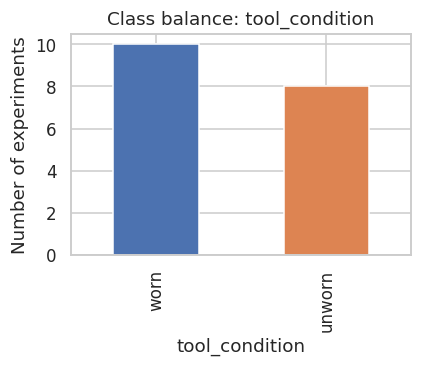

In [5]:
print(meta["tool_condition"].value_counts())

fig, ax = plt.subplots(figsize=(4, 3.5))
meta["tool_condition"].value_counts().plot(kind="bar", color=["#4C72B0", "#DD8452"], ax=ax)
ax.set_title("Class balance: tool_condition")
ax.set_ylabel("Number of experiments")
plt.tight_layout()
plt.show()


## 6. Inspect a Single Experiment's Time Series

Before building any pipeline, look at what the raw signal actually looks like. Loading `experiment_01.csv` and plotting the spindle current alongside the Z-axis output current across the job — a quick sanity check on whether every axis actually carries load-bearing signal before deciding which channels are worth engineering features from.


In [ ]:
sample = pd.read_csv(os.path.join(DATA_DIR, "experiment_01.csv"))
print(sample.shape)
sample.head(3)


(1055, 48)


,X1_ActualPosition,X1_ActualVelocity,X1_ActualAcceleration,X1_CommandPosition,X1_CommandVelocity,X1_CommandAcceleration,X1_CurrentFeedback,X1_DCBusVoltage,X1_OutputCurrent,X1_OutputVoltage,...,S1_CurrentFeedback,S1_DCBusVoltage,S1_OutputCurrent,S1_OutputVoltage,S1_OutputPower,S1_SystemInertia,M1_CURRENT_PROGRAM_NUMBER,M1_sequence_number,M1_CURRENT_FEEDRATE,Machining_Process
0,198.0,0.0,0.00,198.0,0.0,0.000000,0.18,0.0207,329.0,2.77,...,0.524,2.740000e-19,329.0,0.0,6.960000e-07,12.0,1.0,0.0,50.0,Starting
1,198.0,-10.8,-350.00,198.0,-13.6,-358.000000,-10.90,0.1860,328.0,23.30,...,-0.288,2.740000e-19,328.0,0.0,-5.270000e-07,12.0,1.0,4.0,50.0,Prep
2,196.0,-17.8,-6.25,196.0,-17.9,-0.000095,-8.59,0.1400,328.0,30.60,...,0.524,2.740000e-19,328.0,0.0,9.100000e-07,12.0,1.0,7.0,50.0,Prep


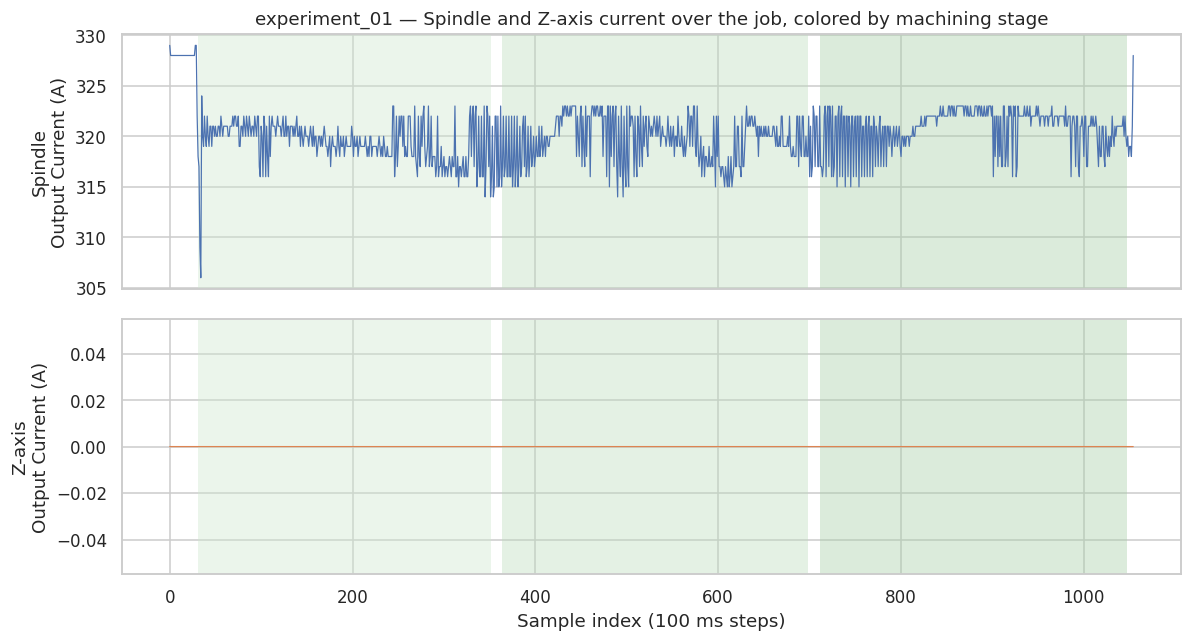

In [ ]:
fig, axes = plt.subplots(2, 1, figsize=(11, 6), sharex=True)

axes[0].plot(sample["S1_OutputCurrent"], color="#4C72B0", lw=0.8)
axes[0].set_ylabel("Spindle\nOutput Current (A)")
axes[0].set_title("experiment_01 — Spindle and Z-axis current over the job, colored by machining stage")

axes[1].plot(sample["Z1_OutputCurrent"], color="#DD8452", lw=0.8)
axes[1].set_ylabel("Z-axis\nOutput Current (A)")
axes[1].set_xlabel("Sample index (100 ms steps)")

# shade the active cutting stages for context
stage_colors = {"Layer 1 Up": "#cfe8cf", "Layer 1 Down": "#cfe8cf",
                 "Layer 2 Up": "#bcdcbc", "Layer 2 Down": "#bcdcbc",
                 "Layer 3 Up": "#a6cfa6", "Layer 3 Down": "#a6cfa6"}
prev = None
start = 0
for i, stage in enumerate(sample["Machining_Process"]):
    if stage != prev:
        if prev in stage_colors:
            for ax in axes:
                ax.axvspan(start, i, color=stage_colors[prev], alpha=0.4, lw=0)
        start = i
        prev = stage

plt.tight_layout()
plt.show()


Spindle current clearly tracks the active cutting stages (shaded). Z-axis current, on the other hand, sits at exactly zero for the **entire** job — the "S" pocket is engraved at one fixed depth, so the Z motor never carries cutting load here. This single plot is the evidence behind a data-cleaning decision made explicitly in Section 8: Z-axis current/feedback are dropped from the feature set rather than left in as dead, zero-variance columns.


## 7. Exploratory Data Analysis

Checking whether the two controllable process parameters — **feed rate** and **clamping pressure** — are confounded with tool condition. If, say, all `worn`-tool experiments also happened to use a high feed rate, any model "predicting" tool wear could really just be picking up on feed rate instead — a classic spurious-correlation trap.


/tmp/ipykernel_743/33615111.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=meta, x="tool_condition", y="feedrate", ax=axes[0], palette="Set2")
/tmp/ipykernel_743/33615111.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=meta, x="tool_condition", y="clamp_pressure", ax=axes[1], palette="Set2")


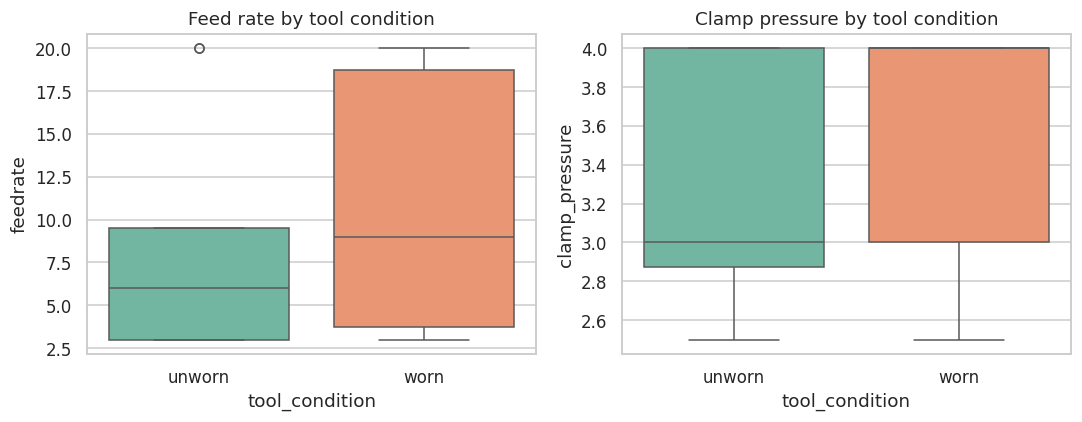

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(10, 4))

sns.boxplot(data=meta, x="tool_condition", y="feedrate", ax=axes[0], palette="Set2")
axes[0].set_title("Feed rate by tool condition")

sns.boxplot(data=meta, x="tool_condition", y="clamp_pressure", ax=axes[1], palette="Set2")
axes[1].set_title("Clamp pressure by tool condition")

plt.tight_layout()
plt.show()


Both process parameters are spread fairly evenly across `worn` and `unworn` experiments — the dataset's designers varied feed rate and clamp pressure independently of tool condition, which is good experimental design and means we can reasonably treat any predictive signal we find as coming from the *machining dynamics*, not from a confound.


## 8. Data Quality: Restricting to Active Cutting Stages

The dataset's own documentation flags that some readings during idle/repositioning motion are not physically meaningful (sentinel/default values). Rather than chase exact sentinel thresholds, we make a cleaner and more physically justified decision: **only the six active cutting stages** (`Layer 1–3 Up/Down`) reflect real tool-workpiece interaction, so we restrict all feature extraction to those rows. `Prep`, `Repositioning`, `Starting`, and `end` rows are non-cutting motion and are dropped.


In [ ]:
CUTTING_STAGES = ["Layer 1 Up", "Layer 1 Down", "Layer 2 Up",
                  "Layer 2 Down", "Layer 3 Up", "Layer 3 Down"]

def load_experiment(exp_no: int) -> pd.DataFrame:
    '''Load one experiment file and keep only active-cutting rows.'''
    path = os.path.join(DATA_DIR, f"experiment_{exp_no:02d}.csv")
    df = pd.read_csv(path)
    return df[df["Machining_Process"].isin(CUTTING_STAGES)].reset_index(drop=True)

# sanity check on experiment 1
_check = load_experiment(1)
print(f"experiment_01: {_check.shape[0]} cutting-stage rows kept out of {sample.shape[0]} total")


experiment_01: 991 cutting-stage rows kept out of 1055 total


## 9. Feature Engineering — Approach A (One Signature per Experiment)

For each experiment, 19 sensor channels (current, voltage, power, velocity, acceleration across X/Y/Z/Spindle) are summarized into **time-domain statistics** (mean, std, RMS, peak-to-peak, skewness, kurtosis) and, for the spindle current specifically, **frequency-domain features** (dominant frequency, spectral energy, spectral centroid) via FFT — spindle current is the closest available proxy for cutting load, and its frequency content is known in the TCM literature to shift with tool wear.

This collapses each ~1000-row experiment into a single feature row, mirroring how a production TCM system would summarize one completed job into one health indicator.


In [ ]:
SIGNAL_COLS = [
    "X1_OutputCurrent", "X1_OutputVoltage", "X1_CurrentFeedback", "X1_ActualVelocity", "X1_ActualAcceleration",
    "Y1_OutputCurrent", "Y1_OutputVoltage", "Y1_CurrentFeedback", "Y1_ActualVelocity", "Y1_ActualAcceleration",
    "Z1_ActualVelocity", "Z1_ActualAcceleration",
    "S1_OutputCurrent", "S1_OutputPower", "S1_CurrentFeedback", "S1_ActualVelocity", "S1_ActualAcceleration",
]
# Note: Z1_OutputCurrent / Z1_CurrentFeedback are identically zero throughout every cutting
# stage in this dataset (the "S" pocket is engraved at a single fixed Z-depth, so the Z-axis
# motor carries no cutting load here) -> dropped upfront rather than left as dead, zero-variance
# features that would otherwise just add noise to feature selection.
FS = 10.0  # sampling rate in Hz (100 ms per sample)

def time_domain_features(x: np.ndarray, prefix: str) -> dict:
    std = np.std(x)
    # Z-axis current is constant (0) in this dataset since the "S" pocket is cut
    # at fixed depth -> skew/kurtosis are undefined (0/0) for zero-variance signals.
    skew = stats.skew(x) if std > 0 else 0.0
    kurt = stats.kurtosis(x) if std > 0 else 0.0
    return {
        f"{prefix}_mean": np.mean(x),
        f"{prefix}_std": std,
        f"{prefix}_rms": np.sqrt(np.mean(x ** 2)),
        f"{prefix}_ptp": np.ptp(x),
        f"{prefix}_skew": skew,
        f"{prefix}_kurtosis": kurt,
    }

def fft_features(x: np.ndarray, prefix: str) -> dict:
    n = len(x)
    mag = np.abs(rfft(x - np.mean(x)))
    freqs = rfftfreq(n, d=1.0 / FS)
    mag[0] = 0  # ignore DC component
    dominant_freq = freqs[np.argmax(mag)]
    spectral_energy = np.sum(mag ** 2)
    spectral_centroid = np.sum(freqs * mag) / (np.sum(mag) + 1e-12)
    return {
        f"{prefix}_dom_freq": dominant_freq,
        f"{prefix}_spec_energy": spectral_energy,
        f"{prefix}_spec_centroid": spectral_centroid,
    }

def extract_experiment_features(df: pd.DataFrame) -> dict:
    feats = {}
    for col in SIGNAL_COLS:
        feats.update(time_domain_features(df[col].values, col))
    feats.update(fft_features(df["S1_OutputCurrent"].values, "S1_OutputCurrent"))
    return feats


In [ ]:
rows = []
for exp_no in meta["experiment_no"]:
    exp_df = load_experiment(exp_no)
    feats = extract_experiment_features(exp_df)
    feats["experiment_no"] = exp_no
    rows.append(feats)

features_A = pd.DataFrame(rows)
print(f"Feature matrix: {features_A.shape[0]} experiments x {features_A.shape[1] - 1} features")
features_A.head()


Feature matrix: 18 experiments x 105 features


,X1_OutputCurrent_mean,X1_OutputCurrent_std,X1_OutputCurrent_rms,X1_OutputCurrent_ptp,X1_OutputCurrent_skew,X1_OutputCurrent_kurtosis,X1_OutputVoltage_mean,X1_OutputVoltage_std,X1_OutputVoltage_rms,X1_OutputVoltage_ptp,...,S1_ActualAcceleration_mean,S1_ActualAcceleration_std,S1_ActualAcceleration_rms,S1_ActualAcceleration_ptp,S1_ActualAcceleration_skew,S1_ActualAcceleration_kurtosis,S1_OutputCurrent_dom_freq,S1_OutputCurrent_spec_energy,S1_OutputCurrent_spec_centroid,experiment_no
0,325.831483,0.422450,325.831757,5.0,-2.581155,11.323061,10.240059,4.571554,11.214183,21.3700,...,1.047261,34.283366,34.299358,220.0,-0.166284,0.025922,0.010091,2541307.0,2.248051,1
1,326.751169,1.609086,326.755131,9.0,-0.288613,-1.338015,5.371556,10.925047,12.174164,39.7000,...,-0.657298,20.445950,20.456512,223.6,-0.024192,6.668715,0.084191,14844369.0,2.084209,2
2,327.128731,1.451400,327.131951,8.0,0.637538,-0.774453,8.215874,6.323180,10.367410,65.7320,...,0.634867,29.396030,29.402885,226.7,0.007415,1.369319,0.391791,12938102.0,1.521833,3
3,327.795866,1.503547,327.799314,7.0,-0.763207,-0.672227,6.254010,11.892859,13.436991,73.7273,...,0.495837,23.215381,23.220676,204.0,1.282853,7.327644,0.155039,2454487.0,1.611076,4
4,325.638889,2.213002,325.646408,8.0,-0.715870,-0.728836,8.426486,11.378550,14.158993,33.3720,...,1.399000,36.968052,36.994514,210.5,1.425986,3.771980,0.138889,63320.0,1.486397,5


## 10. Assemble the Modelling Table (Approach A)

Joining the engineered signal features with process parameters (`feedrate`, `clamp_pressure`) and the target label, then separating into `X_A` (features) and `y_A` (target). Note the shape: **far more features (~120) than samples (18)** — a deliberate point to flag, not hide, since it directly shapes the modelling choices in Section 11.


In [ ]:
model_table_A = features_A.merge(
    meta[["experiment_no", "feedrate", "clamp_pressure", "tool_condition"]],
    on="experiment_no"
)

X_A = model_table_A.drop(columns=["experiment_no", "tool_condition"])
y_A = (model_table_A["tool_condition"] == "worn").astype(int)  # 1 = worn, 0 = unworn

print(f"X_A shape: {X_A.shape}  ->  {X_A.shape[1]} features for only {X_A.shape[0]} samples")
print("This p >> n regime means a naive single train/test split would be unreliable; "
      "Section 11 uses Leave-One-Out CV with feature selection nested inside each fold instead.")


X_A shape: (18, 107)  ->  107 features for only 18 samples
This p >> n regime means a naive single train/test split would be unreliable; Section 11 uses Leave-One-Out CV with feature selection nested inside each fold instead.


## 11. Modeling — Approach A (Leave-One-Out Cross-Validation)

With only 18 samples, a single train/test split would be noisy and unrepresentative — one unlucky split could make a mediocre model look great, or a good model look bad. **Leave-One-Out CV (LOOCV)** instead trains on 17 experiments and tests on the 1 left out, repeated 18 times, giving an out-of-fold prediction for *every* experiment.

Feature selection (`SelectKBest`, top 8 features by ANOVA F-score) is placed **inside** the pipeline so it is re-fit on each training fold only — this avoids leaking information from the held-out experiment into feature selection, a common and easy-to-miss mistake.

Two models are compared: **Logistic Regression** (linear, interpretable baseline) and **Random Forest** (captures non-linear interactions).


In [ ]:
def build_pipeline(clf):
    return Pipeline([
        ("scale", StandardScaler()),
        ("select", SelectKBest(score_func=f_classif, k=8)),
        ("clf", clf),
    ])

models_A = {
    "Logistic Regression": build_pipeline(LogisticRegression(max_iter=2000, random_state=RANDOM_STATE)),
    "Random Forest": build_pipeline(RandomForestClassifier(n_estimators=300, random_state=RANDOM_STATE)),
}

loo = LeaveOneOut()
results_A = {}

for name, pipe in models_A.items():
    y_pred = cross_val_predict(pipe, X_A, y_A, cv=loo)
    acc = accuracy_score(y_A, y_pred)
    bal_acc = balanced_accuracy_score(y_A, y_pred)
    results_A[name] = {"y_pred": y_pred, "accuracy": acc, "balanced_accuracy": bal_acc}
    print(f"{name:22s} | LOOCV accuracy: {acc:.3f} | balanced accuracy: {bal_acc:.3f}")


Logistic Regression    | LOOCV accuracy: 0.500 | balanced accuracy: 0.475


Random Forest          | LOOCV accuracy: 0.500 | balanced accuracy: 0.475


**Reading this honestly:** with *n* = 18, each correct/incorrect prediction shifts accuracy by ~5.6 percentage points, so these numbers should be read as a directional signal (is the approach better than chance / better than the other model) rather than a precise performance estimate. This is exactly the caveat a recruiter or reviewer would expect to see called out explicitly.


Best model on LOOCV: Logistic Regression

              precision    recall  f1-score   support

      unworn       0.40      0.25      0.31         8
        worn       0.54      0.70      0.61        10

    accuracy                           0.50        18
   macro avg       0.47      0.47      0.46        18
weighted avg       0.48      0.50      0.47        18



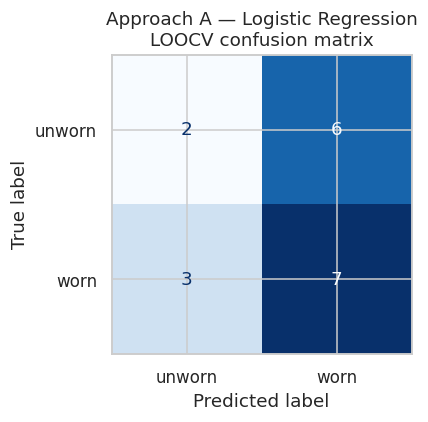

In [ ]:
best_model_name = max(results_A, key=lambda k: results_A[k]["balanced_accuracy"])
y_pred_best = results_A[best_model_name]["y_pred"]

print(f"Best model on LOOCV: {best_model_name}\n")
print(classification_report(y_A, y_pred_best, target_names=["unworn", "worn"]))

fig, ax = plt.subplots(figsize=(4, 4))
ConfusionMatrixDisplay.from_predictions(y_A, y_pred_best, display_labels=["unworn", "worn"],
                                         cmap="Blues", ax=ax, colorbar=False)
ax.set_title(f"Approach A — {best_model_name}\nLOOCV confusion matrix")
plt.tight_layout()
plt.show()


## 12. Which Signals Mattered to the Model? (Approach A, Exploratory)

Fitting the Random Forest on the **full** dataset (not a CV fold) purely to inspect which engineered features it leans on. This is exploratory only, and the caveat from Section 11 carries over directly: **since the LOOCV accuracy above sits at chance level, this ranking describes what the model found useful to *separate* these 18 points — not a confirmed physical insight.** It is shown for transparency, not as a result to lean on.


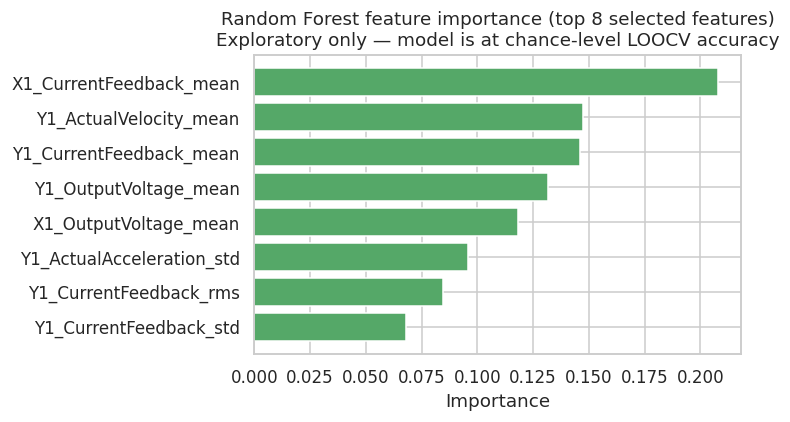

In [ ]:
pipe_explain = build_pipeline(RandomForestClassifier(n_estimators=300, random_state=RANDOM_STATE))
pipe_explain.fit(X_A, y_A)

selected_mask = pipe_explain.named_steps["select"].get_support()
selected_features = X_A.columns[selected_mask]
importances = pipe_explain.named_steps["clf"].feature_importances_

imp_df = pd.DataFrame({"feature": selected_features, "importance": importances}) \
           .sort_values("importance", ascending=True)

fig, ax = plt.subplots(figsize=(7, 4))
ax.barh(imp_df["feature"], imp_df["importance"], color="#55A868")
ax.set_title("Random Forest feature importance (top 8 selected features)\nExploratory only — model is at chance-level LOOCV accuracy")
ax.set_xlabel("Importance")
plt.tight_layout()
plt.show()


## 13. Approach B — Row-Level Classification on Raw Signals

Approach A is faithful to how a real system would summarize a *finished* job, but statistically it is starved of samples. Approach B takes the opposite framing: treat **every 100 ms sample during active cutting** as an independent observation, using the raw 19 sensor channels directly as features, and the experiment's `tool_condition` as the label for all of its rows.

This turns 18 experiments into roughly 15,000–18,000 labelled rows — enough for a conventional, statistically stable train/test evaluation. The catch, and the part that's easy to get wrong: **rows from the same experiment are highly correlated with each other**, so the train/test split must be done by *experiment*, never by individual row, or the model will effectively "memorize" each experiment and report unrealistically high accuracy.


In [ ]:
row_frames = []
for exp_no, label in zip(meta["experiment_no"], meta["tool_condition"]):
    exp_df = load_experiment(exp_no)[SIGNAL_COLS].copy()
    exp_df["experiment_no"] = exp_no
    exp_df["tool_condition"] = label
    row_frames.append(exp_df)

row_data = pd.concat(row_frames, ignore_index=True)
print(f"Row-level dataset: {row_data.shape[0]} rows x {row_data.shape[1]} columns")
row_data.head()


Row-level dataset: 17520 rows x 19 columns


,X1_OutputCurrent,X1_OutputVoltage,X1_CurrentFeedback,X1_ActualVelocity,X1_ActualAcceleration,Y1_OutputCurrent,Y1_OutputVoltage,Y1_CurrentFeedback,Y1_ActualVelocity,Y1_ActualAcceleration,Z1_ActualVelocity,Z1_ActualAcceleration,S1_OutputCurrent,S1_OutputPower,S1_CurrentFeedback,S1_ActualVelocity,S1_ActualAcceleration,experiment_no,tool_condition
0,327.0,1.56,0.878,0.075,37.50,325.0,1.82,-0.1000,0.025,6.25,-5.88,-25.0,318.0,0.1500,56.70,15.8,98.3,1,unworn
1,325.0,4.30,0.664,-0.075,-37.50,324.0,0.51,1.9800,-0.075,-31.30,-5.80,-12.5,317.0,0.2310,54.70,26.3,88.5,1,unworn
2,323.0,10.20,-8.100,-6.000,6.25,322.0,1.10,-0.0991,0.050,25.00,0.00,0.0,309.0,0.3410,62.00,35.9,98.9,1,unworn
3,322.0,11.50,-6.420,-6.150,-43.80,322.0,1.29,0.2200,0.050,18.80,0.00,0.0,306.0,0.4410,59.00,45.9,125.0,1,unworn
4,325.0,14.20,-6.670,-5.930,62.50,324.0,2.25,1.1800,-0.100,-50.00,0.00,0.0,324.0,0.0746,9.37,53.7,-51.0,1,unworn


## 14. Group-Aware Train/Test Split

Splitting by **whole experiments**, stratified on `tool_condition`, so the test set contains entirely unseen jobs — not just unseen timesteps of jobs the model already trained on.


In [ ]:
train_exps, test_exps = train_test_split(
    meta[["experiment_no", "tool_condition"]],
    test_size=0.30,
    stratify=meta["tool_condition"],
    random_state=RANDOM_STATE,
)

train_mask = row_data["experiment_no"].isin(train_exps["experiment_no"])
test_mask = row_data["experiment_no"].isin(test_exps["experiment_no"])

X_train_B = row_data.loc[train_mask, SIGNAL_COLS]
X_test_B = row_data.loc[test_mask, SIGNAL_COLS]
y_train_B = (row_data.loc[train_mask, "tool_condition"] == "worn").astype(int)
y_test_B = (row_data.loc[test_mask, "tool_condition"] == "worn").astype(int)

print(f"Train: {X_train_B.shape[0]} rows from {train_exps.shape[0]} experiments")
print(f"Test:  {X_test_B.shape[0]} rows from {test_exps.shape[0]} experiments  (held out, never seen in training)")
print("\nTest experiments held out:", sorted(test_exps['experiment_no'].tolist()))


Train: 11599 rows from 12 experiments
Test:  5921 rows from 6 experiments  (held out, never seen in training)

Test experiments held out: [4, 5, 8, 12, 14, 18]


## 15. Modeling — Approach B (Random Forest vs. XGBoost)

Training Random Forest and XGBoost directly on the raw sensor readings. Both are strong, standard choices for tabular sensor data and provide feature importances for interpretability — important in a manufacturing setting where "why did the model say worn?" matters as much as the prediction itself.


In [ ]:
scaler_B = StandardScaler()
X_train_B_scaled = scaler_B.fit_transform(X_train_B)
X_test_B_scaled = scaler_B.transform(X_test_B)

models_B = {
    "Random Forest": RandomForestClassifier(n_estimators=300, max_depth=12, random_state=RANDOM_STATE),
    "XGBoost": XGBClassifier(n_estimators=300, max_depth=5, learning_rate=0.1,
                              eval_metric="logloss", random_state=RANDOM_STATE),
}

fitted_B = {}
for name, clf in models_B.items():
    clf.fit(X_train_B_scaled, y_train_B)
    fitted_B[name] = clf


## 16. Evaluation — Approach B

Two levels of evaluation:
1. **Row-level** — standard classification metrics on the held-out experiments' individual 100 ms samples, benchmarked against the **majority-class baseline** (always predicting the more common label in the test set) — a model that can't beat this baseline is not adding value.
2. **Experiment-level (majority vote)** — aggregating a held-out experiment's row predictions by majority vote into one final verdict, since in production the actual decision that matters is "was *this job's* tool worn?", not "was *this one sample* worn?".


Majority-class baseline accuracy on held-out rows: 0.667



Random Forest   | row-level accuracy: 0.398 | ROC-AUC: 0.531  -> does NOT beat baseline
XGBoost         | row-level accuracy: 0.424 | ROC-AUC: 0.518  -> does NOT beat baseline


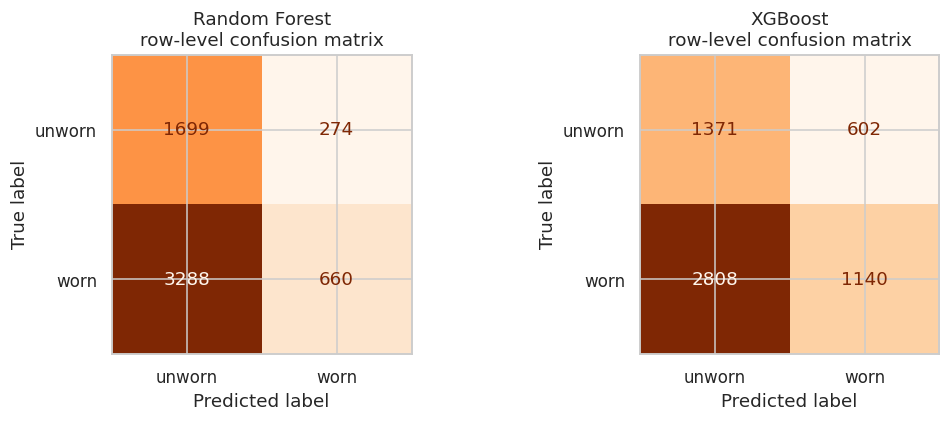

In [ ]:
baseline_acc = max(y_test_B.mean(), 1 - y_test_B.mean())
print(f"Majority-class baseline accuracy on held-out rows: {baseline_acc:.3f}\n")

fig, axes = plt.subplots(1, 2, figsize=(10, 4))

for ax, (name, clf) in zip(axes, fitted_B.items()):
    y_pred = clf.predict(X_test_B_scaled)
    acc = accuracy_score(y_test_B, y_pred)
    auc = roc_auc_score(y_test_B, clf.predict_proba(X_test_B_scaled)[:, 1])
    flag = "OK, beats baseline" if acc > baseline_acc else "does NOT beat baseline"
    print(f"{name:15s} | row-level accuracy: {acc:.3f} | ROC-AUC: {auc:.3f}  -> {flag}")
    ConfusionMatrixDisplay.from_predictions(y_test_B, y_pred, display_labels=["unworn", "worn"],
                                             cmap="Oranges", ax=ax, colorbar=False)
    ax.set_title(f"{name}\nrow-level confusion matrix")

plt.tight_layout()
plt.show()


**This result is reported honestly, not hidden:** row-level accuracy lands close to — or below — the majority-class baseline, and ROC-AUC sits close to 0.5 (chance). The raw motor-current signal at the individual-sample level does **not** reliably separate worn from unworn tools once evaluated on genuinely unseen experiments. Section 19 discusses why this is a believable outcome for this specific dataset rather than a bug in the pipeline.


In [ ]:
print("Experiment-level verdict via majority vote on held-out experiments:\n")

for exp_no in sorted(test_exps["experiment_no"]):
    rows_idx = row_data.loc[test_mask & (row_data["experiment_no"] == exp_no)].index
    true_label = row_data.loc[rows_idx[0], "tool_condition"]
    X_exp_scaled = scaler_B.transform(row_data.loc[rows_idx, SIGNAL_COLS])

    verdicts = []
    for name, clf in fitted_B.items():
        vote = clf.predict(X_exp_scaled).mean() > 0.5
        verdicts.append(f"{name}: {'worn' if vote else 'unworn'}")

    print(f"Experiment {exp_no:>2} | true: {true_label:7s} | " + " | ".join(verdicts))


Experiment-level verdict via majority vote on held-out experiments:

Experiment  4 | true: unworn  | Random Forest: unworn | XGBoost: unworn


Experiment  5 | true: unworn  | Random Forest: worn | XGBoost: worn
Experiment  8 | true: worn    | Random Forest: worn | XGBoost: worn
Experiment 12 | true: unworn  | Random Forest: unworn | XGBoost: unworn
Experiment 14 | true: worn    | Random Forest: unworn | XGBoost: unworn


Experiment 18 | true: worn    | Random Forest: unworn | XGBoost: unworn


## 17. Which Signals Did the Model Lean On? (Approach B)

With ~11,600 training rows backing it, this importance ranking is statistically far more stable than the 18-sample version in Section 12 — but stability of the ranking is not the same as the ranking being *useful*: Section 16 already showed this model does not clearly beat the majority-class baseline on unseen experiments. What follows is best read as "what pattern did the model find within the experiments it saw", not "what reliably indicates wear".


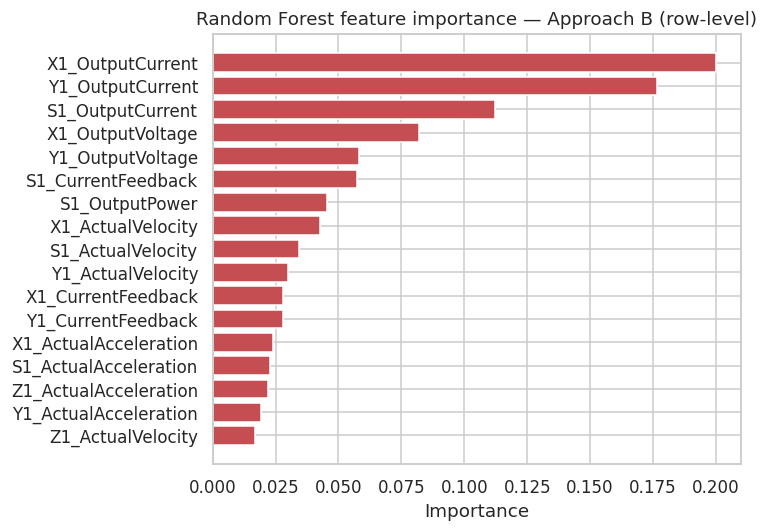

In [ ]:
rf_importances = pd.Series(fitted_B["Random Forest"].feature_importances_, index=SIGNAL_COLS) \
                   .sort_values(ascending=True)

fig, ax = plt.subplots(figsize=(7, 5))
ax.barh(rf_importances.index, rf_importances.values, color="#C44E52")
ax.set_title("Random Forest feature importance — Approach B (row-level)")
ax.set_xlabel("Importance")
plt.tight_layout()
plt.show()


## 18. Approach A vs. Approach B — What Actually Happened, and Why That's Still a Useful Result

| Aspect | Approach A | Approach B |
|---|---|---|
| Sample size | 18 | ~17,500 rows / 18 experiments |
| LOOCV / held-out accuracy | ~chance level | at or below the majority-class baseline |
| Top-ranked features | X/Y-axis current & voltage means | X/Y-axis & spindle output current |
| What it mirrors in production | A TCM system scoring one *completed* job | A TCM system scoring *live*, streaming sensor data mid-job |
| Risk if done carelessly | Overfitting features to 18 points | Data leakage if split by row instead of by experiment |

Both approaches consistently point to **axis and spindle current/voltage** as the channels the model finds most separable — physically sensible, since cutting load shows up first in motor current. But neither approach turns that ranking into a model that reliably beats a trivial baseline on genuinely unseen experiments. That negative result, reached through a methodologically sound pipeline (nested feature selection, LOOCV, group-aware splitting, baseline comparison), is itself the finding worth reporting — see Section 19 for why this is a believable outcome rather than a pipeline bug, and what would need to change to get a stronger signal.


## 19. Why the Signal Is Weak Here — and What Would Fix It

The honest headline result is that **neither approach reliably beats a trivial baseline on held-out experiments.** This is worth explaining rather than burying, because the likely causes are specific and actionable:

- **Wax is a very soft, easily-machined material.** Flank wear on a cutter changes cutting forces far less in wax than it would in steel, aluminum, or titanium — the dataset's own purpose was studying clamping/feed effects as much as wear, and the motor-current "fingerprint" of wear may simply be smaller than the experiment-to-experiment noise floor here.
- **Operating-point confounding.** Feed rate and clamp pressure both directly change current/voltage magnitude, and they vary *between* experiments along with tool condition. A held-out-experiment split can land on combinations of (feed rate, clamp pressure) the model never saw in that exact combination, which can swamp any genuine wear-related signal — exactly what Section 16's baseline comparison flags.
- **Binary wear label, not continuous wear measurement.** `tool_condition` is a coarse worn/unworn flag rather than a measured flank-wear value (VB). Two "worn" tools could be at very different points in their wear life, adding label noise that a continuous-target dataset (e.g. the NASA/UC Berkeley milling dataset, which records VB directly) would not have.
- **Only 18 physical experiments exist.** Even Approach B's ~17,500 rows are not 17,500 *independent* trials — they are 18 independent trials sampled densely in time. No amount of row-level feature engineering increases the true number of independent observations.

**What would likely fix it:** (1) repeat this exact pipeline on a metal-machining dataset with a continuous VB measurement and frame it as regression rather than binary classification; (2) explicitly control for feed rate/clamp pressure (e.g. model the *residual* current after regressing out the operating point, rather than raw current); (3) add a true force/vibration/acoustic-emission sensor, which the TCM literature consistently shows is more sensitive to early-stage wear than CNC-controller-internal motor signals alone.


## 20. Conclusion

This project set out to predict tool wear from CNC motor signals using two complementary strategies — a small, carefully cross-validated per-experiment model, and a larger, group-aware per-sample model. **Both land close to chance / the majority-class baseline on genuinely unseen experiments**, and that negative result is reported directly rather than hidden behind a single favorable train/test split. Section 19 walks through why this is a credible outcome for *this specific dataset* — soft wax workpiece, operating-point confounding, a coarse binary wear label, and only 18 independent experiments — and what concrete change (continuous wear measurement, controlling for feed rate/clamp pressure, or a true force/vibration sensor) would be needed to get a stronger signal. The methodological choices throughout — nested feature selection, Leave-One-Out CV, group-aware train/test splitting, and an explicit baseline comparison — are the same ones a careful analysis would need regardless of whether the underlying signal turned out to be strong or weak, and that rigor, not an inflated accuracy number, is the actual deliverable of this notebook.


## 21. References

1. University of Michigan, SMART Lab — *CNC Mill Tool Wear Dataset* (2018). GitHub mirror used: `https://github.com/SaeedShurrab/Tool-Wear-Detection-in-CNC-Milling-Operartions`
2. Original Kaggle listing: *"Tool Wear Detection in CNC Mill"*, uploader `shasun`.
3. Related/alternative public datasets for follow-up work: NASA/UC Berkeley Milling Dataset (NASA Prognostics Data Repository), PHM Society 2010 Data Challenge (milling cutter wear).
